In [7]:
import pandas as pd
import numpy as np

#Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

#Model
from sklearn.ensemble import RandomForestClassifier

#Evaluasi
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Simpan model
import joblib

Library digunakan untuk:

- mengolah data (pandas, numpy)
- visualisasi data (matplotlib, seaborn)
- preprocessing data
- pembuatan model machine learning
- evaluasi model
- menyimpan model



> **Upload Dataset**






In [2]:
from google.colab import files
uploaded = files.upload()

Saving data_training.csv to data_training.csv


In [29]:
from google.colab import files
uploaded = files.upload()

Saving data_testing.csv to data_testing.csv


Tahap ini dilakukan untuk mengunggah dataset training dan testing ke Google Colab agar dapat diproses menggunakan Python.



> **Membaca Dataset**



In [30]:
train_df = pd.read_csv('data_training.csv')
test_df = pd.read_csv('data_testing.csv')



*   train_df digunakan sebagai data training untuk melatih model klasifikasi.
*   test_df digunakan sebagai data testing untuk prediksi kualitas wine setelah model selesai dilatih.





> **Melihat Data Awal (Data Training)**



Tahap ini dilakukan untuk memahami struktur dataset training, jumlah data, tipe data, serta statistik deskriptif setiap variabel sebelum model dibuat.

In [10]:
print(train_df.head())
print(train_df.info())
print(train_df.describe())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.3             0.740         0.08             1.7      0.094   
1            8.1             0.575         0.22             2.1      0.077   
2           10.1             0.430         0.40             2.6      0.092   
3           12.9             0.500         0.55             2.8      0.072   
4            8.4             0.360         0.32             2.2      0.081   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 10.0                  45.0  0.99576  3.24       0.50   
1                 12.0                  65.0  0.99670  3.29       0.51   
2                 13.0                  52.0  0.99834  3.22       0.64   
3                  7.0                  24.0  1.00012  3.09       0.68   
4                 32.0                  79.0  0.99640  3.30       0.72   

   alcohol  quality    Id  
0      9.8        5  1366  
1      9.2        5   103  
2 

Output pertama menampilkan 5 baris pertama dari dataset training wine quality.

Setiap baris merepresentasikan satu sampel wine dengan berbagai fitur kimiawi seperti:

* fixed acidity
* volatile acidity
* citric acid
* alcohol
* dan variabel target yaitu quality.

Contohnya:

* Data pertama memiliki kualitas (quality) sebesar 5 dengan kadar alkohol (alcohol) 9.8.
* Data ketiga memiliki kualitas 7 dengan kadar alkohol 10.0.

Kolom Id berfungsi sebagai identitas unik tiap data.



> **Mengecek Missing Value**



Pengecekan missing value dilakukan untuk memastikan tidak ada data kosong yang dapat mengganggu proses pelatihan model maupun prediksi data testing.



Pada Data Training

In [31]:
print(train_df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


Pada Data Testing

In [32]:
print(test_df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


* tidak terdapat missing value (data kosong) pada dataset
* seluruh data pada setiap variabel telah terisi lengkap

Karena tidak ada missing value, maka dataset sudah bersih dan dapat langsung digunakan untuk tahap preprocessing, pelatihan model, dan prediksi tanpa perlu melakukan imputasi atau penghapusan data.



> **Memisahkan Fitur dan Target (Data Training)**



Tahap ini hanya menggunakan data training.


*   X berisi fitur-fitur kimiawi wine
*   y berisi target kualitas wine (quality)

Model akan belajar hubungan antara fitur dan target dari data training ini.



In [44]:
x = train_df.drop(['quality', 'Id'], axis=1)
y = train_df['quality']



> **Split Data Training dan Validation**



In [45]:
x_train, x_valid, y_train, y_valid = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

Data training dibagi menjadi:


*   80% data training untuk melatih model
*   20% data validation untuk menguji performa model

Tahap ini masih menggunakan dataset training.





> **Feature Scaling**



Scaling Data Training dan Validation

In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(x_train)
X_valid_scaled = scaler.transform(x_valid)

Scaling Data Testing

In [49]:
# Pisahkan id terlebih dahulu
id_test = test_df['Id']

# Menghapus kolom id karena bukan fitur prediksi
X_test = test_df.drop('Id', axis=1)

# Transform data testing menggunakan scaler dari data training
X_test_scaled = scaler.transform(X_test)

Standardisasi dilakukan agar seluruh fitur memiliki skala yang seimbang sehingga model dapat bekerja lebih optimal.


*   fit_transform() digunakan pada data training karena scaler mempelajari pola data training.
*   transform() digunakan pada validation dan testing agar mengikuti pola scaling dari data training.

Pada tahap ini mulai digunakan data testing untuk persiapan prediksi.





> **Membuat Model Klasifikasi**



**Menggunakan Random Forest Classifier**

Random Forest dipilih karena:

* mampu menangani data klasifikasi dengan baik
* mengurangi overfitting
* memiliki performa yang stabil

Model belajar dari data training untuk mengenali pola kualitas wine.

In [50]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

Berdasarkan output tersebut, model klasifikasi Random Forest berhasil dibuat dan dilatih menggunakan 200 decision tree. Model telah mempelajari pola hubungan antara fitur kimiawi wine dan kualitas wine pada data training. Status Fitted menunjukkan bahwa model siap digunakan untuk evaluasi performa dan prediksi kualitas wine pada data testing.



> **Evaluasi Model**



Evaluasi dilakukan menggunakan:

* accuracy
* confusion matrix
* classification report

Tahap evaluasi masih menggunakan bagian dari data training yaitu validation set.

Tujuannya untuk mengetahui seberapa baik model memprediksi kualitas wine sebelum digunakan pada data testing.

Prediksi Validation

In [51]:
y_pred = model.predict(X_valid_scaled)

Akurasi

In [52]:
accuracy = accuracy_score(y_valid, y_pred)

print("Akurasi:", accuracy)

Akurasi: 0.6162790697674418


Confusion Matrix

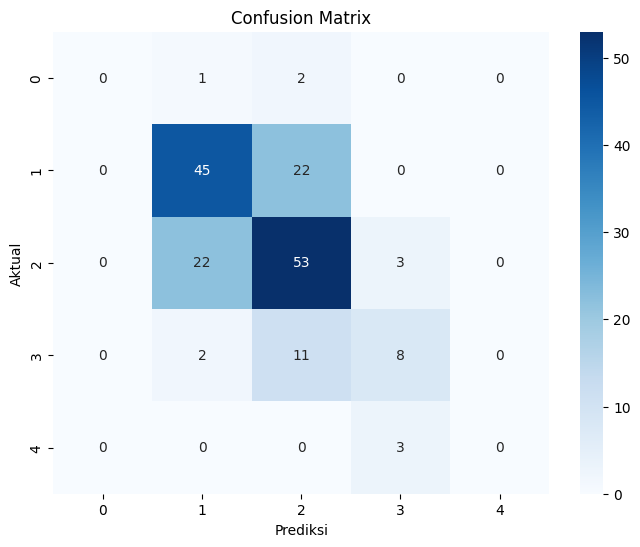

In [53]:
cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

Confusion matrix menunjukkan bahwa model Random Forest memiliki performa yang cukup baik dalam memprediksi kualitas wine. Hal ini terlihat dari banyaknya prediksi benar pada diagonal utama. Namun, model masih mengalami beberapa kesalahan prediksi antar kelas yang memiliki karakteristik serupa. Secara keseluruhan, model sudah cukup layak digunakan untuk melakukan prediksi pada data testing.

Classification Report

In [54]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.64      0.67      0.66        67
           6       0.60      0.68      0.64        78
           7       0.57      0.38      0.46        21
           8       0.00      0.00      0.00         3

    accuracy                           0.62       172
   macro avg       0.36      0.35      0.35       172
weighted avg       0.59      0.62      0.60       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Berdasarkan classification report, model Random Forest memiliki performa cukup baik dengan akurasi sebesar 62%. Model mampu memprediksi kelas kualitas wine 5 dan 6 dengan cukup baik, namun masih kesulitan mengenali kelas minoritas seperti quality 4 dan 8 karena jumlah datanya sangat sedikit. Secara keseluruhan, model sudah cukup baik digunakan untuk prediksi kualitas wine, meskipun performanya pada kelas tertentu masih dapat ditingkatkan.



> **Menyimpan Model**



In [55]:
joblib.dump(model, 'model_wine.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

Model dan scaler disimpan agar dapat digunakan kembali pada proses deployment dan prediksi data baru tanpa perlu melatih ulang model.



> **Deployment pada Data Testing**



Load Model

In [56]:
loaded_model = joblib.load('model_wine.pkl')
loaded_scaler = joblib.load('scaler.pkl')

Prediksi Data Testing

In [57]:
prediksi_test = loaded_model.predict(X_test_scaled)

Tahap ini mulai sepenuhnya menggunakan data testing.

Model yang telah dilatih menggunakan data training digunakan untuk memprediksi nilai quality pada data testing yang belum memiliki label.

Inilah proses deployment model.



> **Membuat File Hasil Prediksi**



In [58]:
hasil_prediksi = pd.DataFrame({
    'id': id_test,
    'quality': prediksi_test
})

Cek hasil:

In [59]:
print(hasil_prediksi.head())

     id  quality
0   222        5
1  1514        5
2   417        5
3   754        5
4   516        5


Output tersebut menampilkan 5 baris pertama hasil prediksi kualitas wine pada dataset testing.

Kolom yang ditampilkan terdiri dari:

* `id` → identitas data wine
* `quality` → hasil prediksi kualitas wine dari model Random Forest

Contoh:

* data dengan `id` 222 diprediksi memiliki kualitas wine sebesar 5
* data dengan `id` 1514 diprediksi memiliki kualitas 5
* data dengan `id` 417 diprediksi memiliki kualitas 5

Hasil ini diperoleh setelah model yang telah dilatih menggunakan data training melakukan prediksi pada data testing yang sebelumnya belum memiliki label kualitas (`quality`).

Output tersebut juga menunjukkan bahwa proses deployment model berhasil dilakukan dan hasil prediksi telah berhasil disimpan dalam format yang sesuai ketentuan, yaitu hanya memuat kolom `id` dan `quality`.




> **Simpan CSV**


In [60]:
hasil_prediksi.to_csv('hasilprediksi_070.csv', index=False)

Hasil prediksi disimpan dalam format CSV sesuai ketentuan pengumpulan tugas.



> **Download File CSV**



In [61]:
files.download('hasilprediksi_070.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File CSV hasil prediksi diunduh untuk kemudian dikumpulkan pada form yang telah disediakan.



> **Kesimpulan**



Berdasarkan hasil analisis dan pembuatan model klasifikasi menggunakan algoritma Random Forest, diperoleh model yang mampu memprediksi kualitas wine berdasarkan fitur-fitur kimiawi yang tersedia pada dataset. Tahapan preprocessing seperti pengecekan missing value dan standardisasi data berhasil dilakukan dengan baik sehingga data siap digunakan untuk pelatihan model. Hasil evaluasi menunjukkan bahwa model memiliki performa yang cukup baik dengan akurasi sekitar 62%, terutama dalam memprediksi kualitas wine pada kelas 5 dan 6. Setelah model selesai dilatih dan dievaluasi, model digunakan untuk melakukan deployment pada data testing guna memprediksi nilai quality yang belum diketahui. Hasil prediksi kemudian berhasil disimpan dalam format CSV sesuai ketentuan, yaitu hanya memuat kolom id dan quality. Secara keseluruhan, model Random Forest cukup efektif digunakan untuk prediksi kualitas wine pada dataset yang diberikan.